In [1]:
import urllib.request
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("stars.csv")

In [4]:
# Rimuove spazi bianchi dai nomi delle colonne
df.columns = df.columns.str.strip()

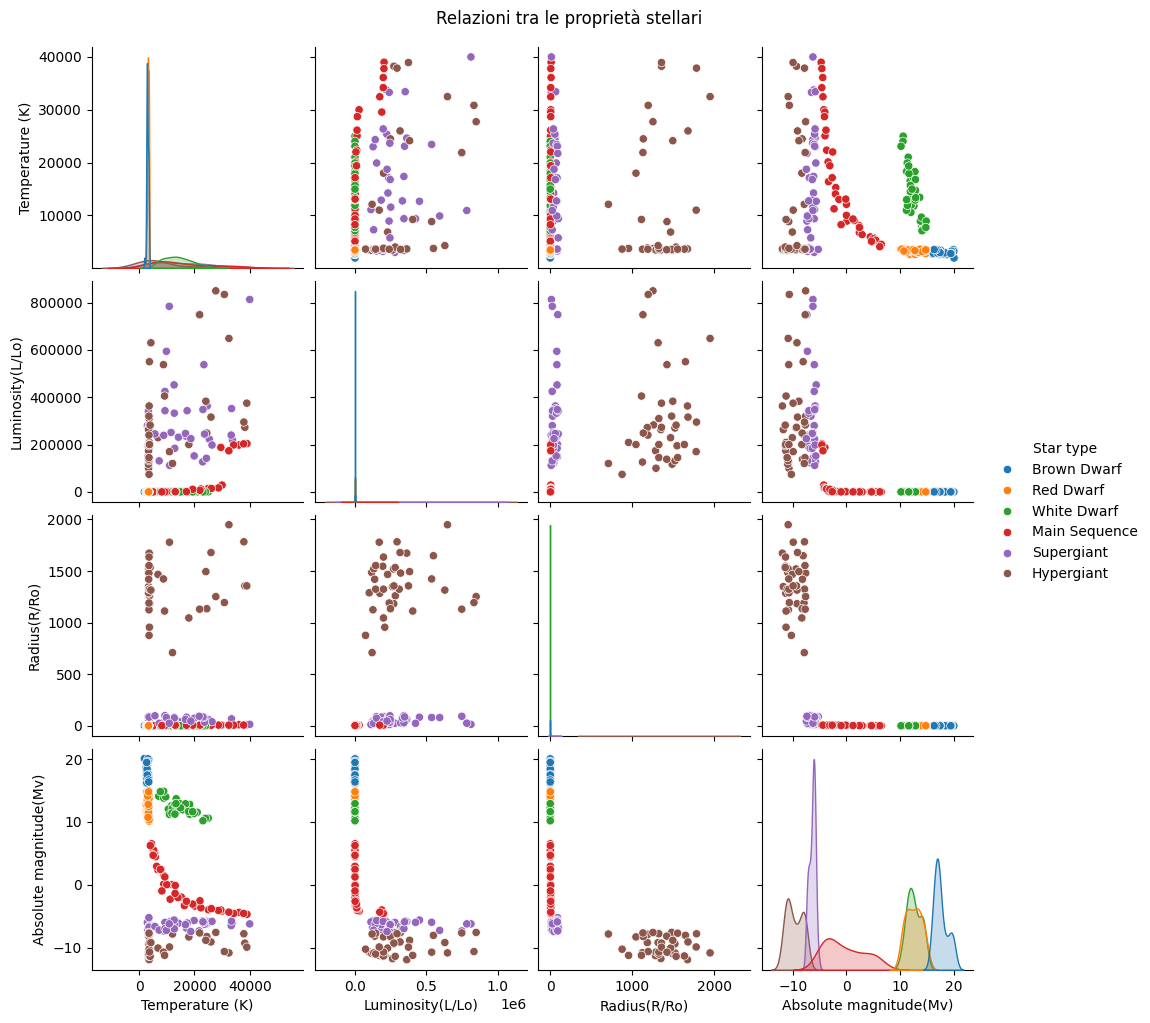

In [5]:
# Step 4: Pairplot
sns.pairplot(df, hue='Star type', diag_kind='kde')
plt.suptitle("Relazioni tra le proprietà stellari", y=1.02)
plt.show()

In [6]:
# Step 5: Encoding delle variabili categoriche
label_encoders = {}
for col in ['Star color', 'Spectral Class', 'Star type']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# Step 6: Standardizzazione delle feature numeriche + categoriche codificate
features = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 
            'Absolute magnitude(Mv)', 'Star color', 'Spectral Class']
X = df[features]
X_scaled = StandardScaler().fit_transform(X)

In [8]:
# Step 7: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

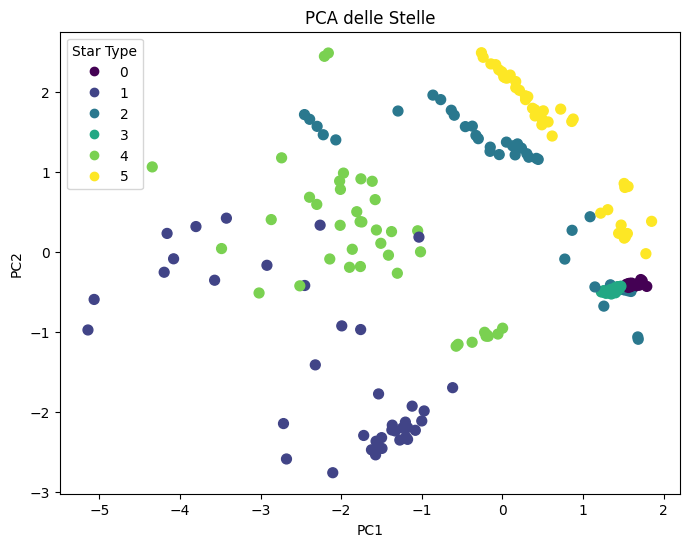

In [9]:
# Step 8: Visualizzazione PCA
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Star type'], cmap='viridis', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA delle Stelle')
plt.legend(*scatter.legend_elements(), title="Star Type")
plt.show()

In [10]:
# Step 9: Varianza spiegata
explained = pca.explained_variance_ratio_
print(f"Varianza spiegata da PC1: {explained[0]:.2f}")
print(f"Varianza spiegata da PC2: {explained[1]:.2f}")

Varianza spiegata da PC1: 0.45
Varianza spiegata da PC2: 0.25
